## Minimization by Cubic Interpolation

Cubic interpolation offers a faster but less reliable method of minimization
than golden section search.

The idea is to fit a cubic polynomial to three points in the function (or four values $f(x)$ and $f'(x)$ of two points), and then finding the minimum of that polynomial. It then replaces the worst point with the new point, and continues the process until convergence.


Consider the function $f(x) = −7 \ln x − 3 \ln(1 − x)$. Explain how to find the minimum of $f(x)$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function to plot
def f(x):
    return -7 * np.log(x) - 3 * np.log(1 - x)

# Create an array of x values between 0 and 1
x = np.linspace(0.001, 0.999, 1000)

# Plot the function
plt.plot(x, f(x))

# Set the title and labels
plt.title('Plot of f(x) = −7 ln(x) − 3 ln(1 − x)')
plt.xlabel('x')
plt.ylabel('f(x)')

# Show the plot
plt.show()


In [ ]:

# Define the cubic interpolation function
def cubic_interpolation(f, x0, x1, x2, tol):
    # Iterate until convergence
    while abs(x2 - x0) > tol:
        f0, f1, f2 = f(x0), f(x1), f(x2)
        
        # Compute the cubic interpolation point
        a = f0
        b = (f1 - f0) / (x1 - x0)
        c = ((f2 - f0) / (x2 - x0) - b) / (x2 - x1)
        x = (x0 + x1) / 2 - b / (2 * c)
        
        # Evaluate the function at the new point
        fx = f(x)
        # Update the bracketing points
        if x < x1:
            if fx < f1:
                x2, x1, x0 = x1, x, x0
                f2, f1, f0 = f1, fx, f0
            else:
                x0 = x
                f0 = fx
        else:
            if fx < f1:
                x0, x1, x2 = x1, x, x2
                f0, f1, f2 = f1, fx, f2
            else:
                x2 = x
                f2 = fx
        print([x0,x1,x2])
    return x1

In [ ]:
# Define initial bracketing points
x0 = 0.01
x1 = 0.5
x2 = 0.9

# Set tolerance for convergence
tol = 1e-6


x1 = cubic_interpolation(f, x0, x1, x2, tol)
f1 = f(x1)

# Print the minimum point and function value
print("Minimum point:", x1)
print("Minimum value:", f1)

**Ex**. Armstrong (Narcissistic) Numbers


An Armstrong number (or narcissistic number) is an integer such that the sum of its own digits each raised to the power of the number of digits equals the number itself. For example, 153 is an Armstrong number because:

$1^3 + 5^3 + 3^3 = 1 + 125 + 27 = 153$

Write a program that prints all Armstrong numbers between 1 and 1000.


## Brent’s Method for 1D Minimization

Brent’s method is a **derivative-free** algorithm for finding the minimum of a **unimodal** function on an interval.
It is widely used because it is both:

- **Robust** (like **golden section search**: it always keeps a valid bracket and shrinks it), and
- **Fast on smooth functions** (by attempting **parabolic interpolation** to jump close to the minimizer).

At each iteration, Brent’s method keeps a **bracket** \(a < b < c\) such that \(f(b) < f(a)\) and \(f(b) < f(c)\).
It then does:

1. **Try a parabolic step**: fit a parabola through three points near the current best point and move to its minimizer (fast if the function is smooth).
2. **Fallback to golden section** if the parabolic step looks unreliable (outside the bracket, too small, or doesn’t reduce the interval safely).

This hybrid strategy gives the reliability of golden-section search with the typical speed of interpolation methods.

**Question.** Suppose $f$ is unimodal on \([a,c]\) and you have a bracket \(a<b<c\) with $f(b)$ the smallest among the three. Explain why a pure parabolic step can fail, and how Brent’s fallback to a golden-section step fixes that.

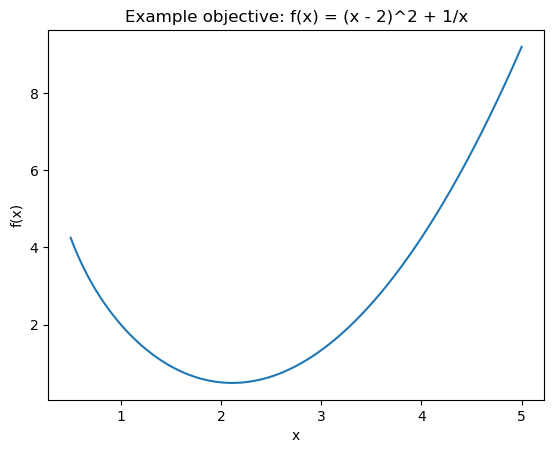

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Example function (unimodal on [0.5, 5])
# f(x) = (x - 2)^2 + 1/x

def f(x):
    return (x - 2.0)**2 + 1.0/x

x = np.linspace(0.5, 5.0, 600)
plt.plot(x, f(x))
plt.title('Example objective: f(x) = (x - 2)^2 + 1/x')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

In [2]:
import math

def brent_minimize(f, a, b, c, tol=1e-8, max_iter=200):
    # Brent's method for 1D minimization on a bracket.
    # Requirements: a < b < c and f(b) < f(a), f(b) < f(c)

    # Golden ratio complement
    invphi = 0.3819660112501051  # (3 - sqrt(5)) / 2

    x = w = v = b
    fx = fw = fv = f(x)

    d = e = 0.0  # movement steps

    for it in range(max_iter):
        m = 0.5 * (a + c)
        tol1 = tol * abs(x) + 1e-12
        tol2 = 2.0 * tol1

        # Stopping criterion: x is close to midpoint of bracket
        if abs(x - m) <= (tol2 - 0.5 * (c - a)):
            return x, fx, it

        p = q = r = 0.0
        if abs(e) > tol1:
            # Attempt parabolic interpolation using points x, w, v
            r = (x - w) * (fx - fv)
            q = (x - v) * (fx - fw)
            p = (x - v) * q - (x - w) * r
            q = 2.0 * (q - r)
            if q > 0:
                p = -p
            q = abs(q)

            # Save previous movement
            e_temp = e
            e = d

            # Accept parabolic step only if it is within the bracket and not too large
            if (abs(p) < abs(0.5 * q * e_temp)) and (p > q * (a - x)) and (p < q * (c - x)):
                d = p / q
                u = x + d
                # If u is too close to the ends, adjust
                if (u - a) < tol2 or (c - u) < tol2:
                    d = tol1 if (m - x) >= 0 else -tol1
            else:
                # Golden-section step
                e = (c - x) if x < m else (a - x)
                d = invphi * e
        else:
            # Golden-section step
            e = (c - x) if x < m else (a - x)
            d = invphi * e

        # Evaluate at new point
        u = x + d if abs(d) >= tol1 else (x + (tol1 if d > 0 else -tol1))
        fu = f(u)

        # Update bracket and the three best points
        if fu <= fx:
            if u < x:
                c = x
            else:
                a = x
            v, fv = w, fw
            w, fw = x, fx
            x, fx = u, fu
        else:
            if u < x:
                a = u
            else:
                c = u
            if (fu <= fw) or (w == x):
                v, fv = w, fw
                w, fw = u, fu
            elif (fu <= fv) or (v == x) or (v == w):
                v, fv = u, fu

    # If max_iter hit, return best found
    return x, fx, max_iter

In [3]:
# A simple way to pick an initial bracket for this example:
# (a, b, c) = (0.5, 2.0, 5.0) works because f(2.0) is smaller than endpoints.

a, b, c = 0.5, 2.0, 5.0
print('f(a), f(b), f(c) =', f(a), f(b), f(c))

xmin, fmin, it = brent_minimize(f, a, b, c, tol=1e-10)
print('xmin =', xmin)
print('f(xmin) =', fmin)
print('iterations =', it)

# Compare with a dense grid search (for sanity)
xgrid = np.linspace(a, c, 20001)
xgrid_min = xgrid[np.argmin([f(xx) for xx in xgrid])]
print('grid approx xmin =', xgrid_min, ' f =', f(xgrid_min))

f(a), f(b), f(c) = 4.25 0.5 9.2
xmin = 2.1120849355475078
f(xmin) = 0.48602884050509537
iterations = 14
grid approx xmin = 2.112125  f = 0.4860288422806193


**Ex. Brent vs. Golden Section (practice)**

Let \(g(x) = x^4 - 3x^3 + 2\).

1. Plot \(g(x)\) on \([0, 3]\) and argue it has a unique minimum on this interval.
2. Find a bracket \(a<b<c\) within \([0,3]\) such that \(g(b) < g(a)\) and \(g(b) < g(c)\).
3. Use your `brent_minimize` implementation to approximate the minimizer and minimum value (use `tol=1e-8`).
4. (Optional) Implement golden section search and compare the number of function evaluations needed to reach the same tolerance.